# Credit Card Fraud Detection using Machine Learning

**Lakshay** &nbsp;|&nbsp; Roll No: AP24110010677 &nbsp;|&nbsp; B.Tech CSE
&nbsp;|&nbsp; SRM University - AP
Supervisor: Mr. Ajay Dilip Kumar Marapatla

> Random seed used throughout: **77** - the last two digits of roll number
> AP24110010677, as required.

---

# Notebook 04 - Instance Based Learning: K-Nearest Neighbour

**Syllabus coverage - UNIT II**

| Topic from the unitization plan | Where it appears below |
|---|---|
| Instance based Learning: K nearest neighbor | Sections 1-2 |
| K nearest neighbor, numerical problem | Section 3 |
| The Curse of Dimensionality | Section 7 |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import utils
from utils import SEED

print(utils.HEADER)
df = utils.load_data()
X_train, X_test, y_train, y_test = utils.make_split(df)


Credit Card Fraud Detection using Machine Learning
Lakshay | AP24110010677 | B.Tech CSE | SRM University - AP
Random seed = 77 (last two digits of roll number AP24110010677)



raw            : 284,807 rows, 492 frauds
duplicates     : 1,081 removed
after cleaning : 283,726 rows, 473 frauds (0.1667%)
train : 198,608 rows, 331 frauds
test  : 85,118 rows, 142 frauds


## 1. Instance based learning

k-NN belongs to the family of **instance based** or **lazy** learners. Unlike a
decision tree, it builds no model at training time - it simply stores the
training examples. All the work happens when a prediction is requested: the
algorithm finds the k stored examples closest to the query point and returns the
majority class among them.

The consequences of this design:

| Property | Decision tree (eager) | k-NN (lazy) |
|---|---|---|
| Training cost | High - builds the tree | Essentially zero - stores the data |
| Prediction cost | Very low - walk one path | High - compare against every stored point |
| Model produced | An explicit set of rules | None; the data *is* the model |
| Target function | One global approximation | A different local approximation per query |

The last row is the important one conceptually. k-NN never forms a single global
hypothesis; it approximates the target function **locally** around each query,
which lets it fit very irregular decision boundaries.

**Inductive bias.** k-NN assumes that instances close together in the attribute
space have the same class. That assumption does all the work, and it is why the
distance measure and the scaling of attributes matter so much.

## 2. The distance measure

The similarity between two instances $x_i$ and $x_j$ described by n attributes
is measured by **Euclidean distance**:

$$ d(x_i, x_j) = \sqrt{\sum_{k=1}^{n} (x_{ik} - x_{jk})^2} $$

Because this is a sum over raw attribute values, an attribute measured on a
large scale dominates the sum. In our data `Amount` ranges up to about 25,000
while the principal components sit within roughly +/-5, so without
standardisation the distance would be decided almost entirely by `Amount`.
Every attribute is therefore standardised to zero mean and unit variance before
the distance is computed - and, critically, the scaler is fitted on the
**training data only**, inside a pipeline, so no information from the test set
leaks into training.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
print("Attribute ranges BEFORE standardisation (a few examples):")
print(X_train[["Amount", "Time", "V1", "V14"]].describe().loc[["min", "max", "std"]].round(2))

Xtr_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
print("\nAfter standardisation:")
print(Xtr_s[["Amount", "Time", "V1", "V14"]].describe().loc[["min", "max", "std"]].round(2))

Attribute ranges BEFORE standardisation (a few examples):
       Amount       Time     V1    V14
min      0.00       0.00 -41.93 -18.82
max  19656.53  172792.00   2.45  10.53
std    252.13   47453.56   1.94   0.95

After standardisation:
     Amount  Time     V1    V14
min   -0.35 -2.00 -21.58 -19.72
max   77.61  1.64   1.26  11.03
std    1.00  1.00   1.00   1.00


## 3. Numerical problem - k-NN worked by hand

To show the algorithm doing exactly what Unit II describes, one test transaction
is classified step by step using only NumPy, and the result is then checked
against scikit-learn.

In [3]:
# Take a small, readable training sample and one query point
np.random.seed(SEED)
small_idx = np.random.choice(len(X_train), 8, replace=False)
train_small = Xtr_s.iloc[small_idx].values
labels_small = np.asarray(y_train)[small_idx]

Xte_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
query_idx = int(np.flatnonzero(np.asarray(y_test) == 1)[0])   # a real fraud case
query = Xte_s.iloc[query_idx].values
true_label = int(np.asarray(y_test)[query_idx])

print(f"Query = test transaction #{query_idx}, true class = "
      f"{'FRAUD' if true_label else 'legitimate'}")
print(f"Using a training sample of {len(train_small)} points for a readable calculation.\n")

print("STEP 1 - Euclidean distance from the query to each stored example")
print("-" * 64)
dists = []
for i, (pt, lab) in enumerate(zip(train_small, labels_small)):
    diff = query - pt
    sq = np.sum(diff ** 2)
    d = np.sqrt(sq)
    dists.append(d)
    print(f"  point {i}  (class {lab})  :  sqrt(sum of squared differences) "
          f"= sqrt({sq:.4f}) = {d:.4f}")

Query = test transaction #1333, true class = FRAUD
Using a training sample of 8 points for a readable calculation.

STEP 1 - Euclidean distance from the query to each stored example
----------------------------------------------------------------
  point 0  (class 0)  :  sqrt(sum of squared differences) = sqrt(237.4300) = 15.4088
  point 1  (class 0)  :  sqrt(sum of squared differences) = sqrt(253.7237) = 15.9287
  point 2  (class 0)  :  sqrt(sum of squared differences) = sqrt(233.8573) = 15.2924
  point 3  (class 0)  :  sqrt(sum of squared differences) = sqrt(265.6727) = 16.2995
  point 4  (class 0)  :  sqrt(sum of squared differences) = sqrt(261.8955) = 16.1832
  point 5  (class 0)  :  sqrt(sum of squared differences) = sqrt(227.6760) = 15.0889
  point 6  (class 0)  :  sqrt(sum of squared differences) = sqrt(250.1756) = 15.8169
  point 7  (class 0)  :  sqrt(sum of squared differences) = sqrt(223.7136) = 14.9571


In [4]:
print("STEP 2 - sort the distances in increasing order")
print("-" * 64)
order = np.argsort(dists)
for rank, i in enumerate(order, 1):
    print(f"  rank {rank}: point {i}  distance {dists[i]:.4f}  class {labels_small[i]}")

k = 3
print(f"\nSTEP 3 - take the k = {k} nearest neighbours")
print("-" * 64)
nn = order[:k]
for i in nn:
    print(f"  point {i}  distance {dists[i]:.4f}  class {labels_small[i]}")

print(f"\nSTEP 4 - majority vote among those {k} neighbours")
print("-" * 64)
votes = labels_small[nn]
n_fraud_votes = int(votes.sum()); n_legit_votes = k - n_fraud_votes
print(f"  votes for class 0 (legitimate) : {n_legit_votes}")
print(f"  votes for class 1 (fraud)      : {n_fraud_votes}")
pred = 1 if n_fraud_votes > n_legit_votes else 0
print(f"\n  PREDICTION = {'FRAUD' if pred else 'legitimate'}")
print(f"  TRUE LABEL = {'FRAUD' if true_label else 'legitimate'}")

STEP 2 - sort the distances in increasing order
----------------------------------------------------------------
  rank 1: point 7  distance 14.9571  class 0
  rank 2: point 5  distance 15.0889  class 0
  rank 3: point 2  distance 15.2924  class 0
  rank 4: point 0  distance 15.4088  class 0
  rank 5: point 6  distance 15.8169  class 0
  rank 6: point 1  distance 15.9287  class 0
  rank 7: point 4  distance 16.1832  class 0
  rank 8: point 3  distance 16.2995  class 0

STEP 3 - take the k = 3 nearest neighbours
----------------------------------------------------------------
  point 7  distance 14.9571  class 0
  point 5  distance 15.0889  class 0
  point 2  distance 15.2924  class 0

STEP 4 - majority vote among those 3 neighbours
----------------------------------------------------------------
  votes for class 0 (legitimate) : 3
  votes for class 1 (fraud)      : 0

  PREDICTION = legitimate
  TRUE LABEL = FRAUD


In [5]:
# Verify the hand calculation against scikit-learn on the same 8 points
from sklearn.neighbors import KNeighborsClassifier

check = KNeighborsClassifier(n_neighbors=k).fit(train_small, labels_small)
sk_pred = int(check.predict(query.reshape(1, -1))[0])
sk_dist, sk_idx = check.kneighbors(query.reshape(1, -1))
print("scikit-learn on the same 8 points")
print(f"  neighbour indices : {sk_idx[0]}   (hand calculation: {nn})")
print(f"  distances         : {np.round(sk_dist[0], 4)}")
print(f"  prediction        : {sk_pred}   (hand calculation: {pred})")
print(f"\n  match: {sk_pred == pred and list(sk_idx[0]) == list(nn)}")

scikit-learn on the same 8 points
  neighbour indices : [7 5 2]   (hand calculation: [7 5 2])
  distances         : [14.9571 15.0889 15.2924]
  prediction        : 0   (hand calculation: 0)

  match: True


## 4. Choosing k

k controls the bias-variance trade-off:

- **k = 1** gives the most complex decision boundary. Every training point
  defines its own neighbourhood, so the model fits noise - classic overfitting.
- **large k** smooths the boundary. Too large and the neighbourhood spans
  regions of both classes, which underfits. With 473 frauds in 283,726 records,
  a neighbourhood of size 500 would almost never contain a fraud majority.

The value is chosen by cross validation rather than by guessing.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# k-NN prediction costs O(n_train x n_test). Subsample the TRAINING set only,
# keeping every fraud case. The test set is untouched.
X_sub, y_sub = utils.subsample_train(X_train, y_train, 60000)
print(f"training subsample : {len(y_sub):,} rows, {int(y_sub.sum())} frauds "
      f"(all frauds kept)")

k_rows = []
for kk in [1, 3, 5, 7, 9, 15]:
    pipe = Pipeline([("scaler", StandardScaler()),
                     ("knn", KNeighborsClassifier(n_neighbors=kk, n_jobs=-1))])
    s = cross_val_score(pipe, X_sub, y_sub, cv=3,
                        scoring="average_precision", n_jobs=1)
    k_rows.append({"k": kk, "cv_pr_auc": s.mean(), "std": s.std()})
    print(f"  k={kk:>2} : PR-AUC = {s.mean():.4f}  (+/- {s.std():.4f})")

kd = pd.DataFrame(k_rows)
best_k = int(kd.loc[kd["cv_pr_auc"].idxmax(), "k"])
print(f"\nBest k by cross validation: {best_k}")

training subsample : 60,000 rows, 331 frauds (all frauds kept)


  k= 1 : PR-AUC = 0.6544  (+/- 0.0118)


  k= 3 : PR-AUC = 0.7882  (+/- 0.0387)


  k= 5 : PR-AUC = 0.8042  (+/- 0.0279)


  k= 7 : PR-AUC = 0.8088  (+/- 0.0262)


  k= 9 : PR-AUC = 0.8048  (+/- 0.0265)


  k=15 : PR-AUC = 0.8082  (+/- 0.0350)

Best k by cross validation: 7


saved figure -> Results/figures/04_k_selection.png


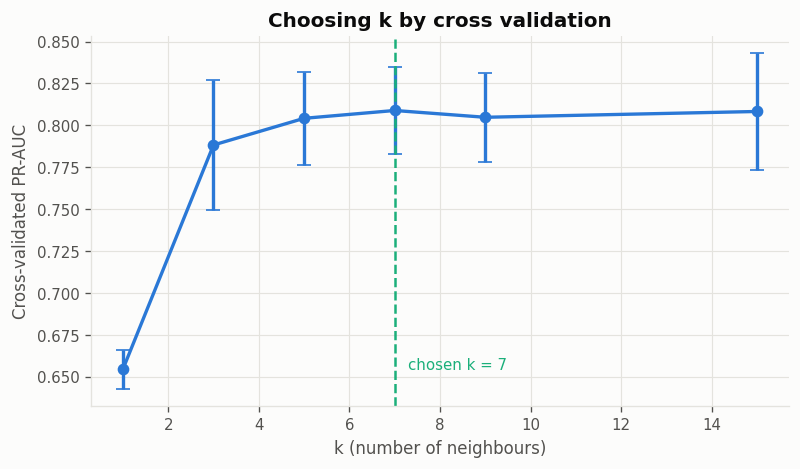

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.errorbar(kd["k"], kd["cv_pr_auc"], yerr=kd["std"], marker="o",
            color=utils.BLUE, capsize=4)
ax.axvline(best_k, color=utils.GREEN, linestyle="--", linewidth=1.5)
ax.text(best_k + 0.3, kd["cv_pr_auc"].min(), f"chosen k = {best_k}",
        color=utils.GREEN, fontsize=9)
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("Cross-validated PR-AUC")
ax.set_title("Choosing k by cross validation")
utils.despine(ax)
utils.save_fig(fig, "04_k_selection.png")
plt.show()

saved figure -> Results/figures/04_error_rate.png


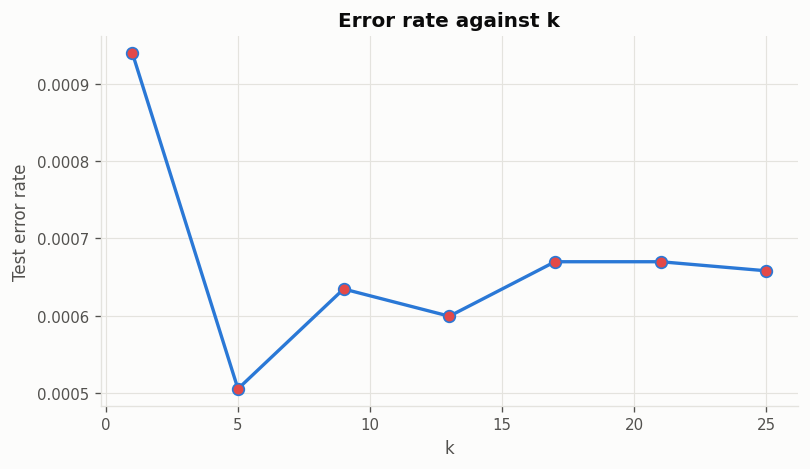

In [8]:
# The classic error-rate-against-k curve
err = []
for kk in range(1, 26, 4):
    p = Pipeline([("scaler", StandardScaler()),
                  ("knn", KNeighborsClassifier(n_neighbors=kk, n_jobs=-1))]).fit(X_sub, y_sub)
    err.append(np.mean(p.predict(X_test) != np.asarray(y_test)))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(range(1, 26, 4), err, marker="o", color=utils.BLUE,
        markerfacecolor=utils.RED, markersize=7)
ax.set_xlabel("k"); ax.set_ylabel("Test error rate")
ax.set_title("Error rate against k")
utils.despine(ax)
utils.save_fig(fig, "04_error_rate.png")
plt.show()

Note how small the error rate is across the whole range, and how little it
moves. That is the imbalance again: misclassifying every fraud would still give
an error rate of only 0.17%. This curve is exactly why the k above was chosen on
PR-AUC rather than on error rate.

## 5. Training the final model

In [9]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)),
])
knn.fit(X_sub, y_sub)
print(knn)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_jobs=-1, n_neighbors=7))])


In [10]:
y_pred  = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)[:, 1]
res = utils.evaluate("K-Nearest Neighbour", y_test, y_pred, y_proba,
                     unit="Unit II - Instance based learning")
res["note"] = f"trained on a {len(y_sub):,}-row stratified subsample (all frauds kept)"
utils.save_result(res, y_proba)


===== K-Nearest Neighbour =====
syllabus  : Unit II - Instance based learning
accuracy  : 0.99937
precision : 0.8438
recall    : 0.7606
f1-score  : 0.8000
PR-AUC    : 0.7897
ROC-AUC   : 0.9326
confusion : TN=84,956  FP=20  FN=34  TP=108

              precision    recall  f1-score   support

  Legitimate     0.9996    0.9998    0.9997     84976
       Fraud     0.8438    0.7606    0.8000       142

    accuracy                         0.9994     85118
   macro avg     0.9217    0.8802    0.8998     85118
weighted avg     0.9993    0.9994    0.9993     85118

saved result -> Results/tables/k_nearest_neighbour.json


saved figure -> Results/figures/04_confusion.png


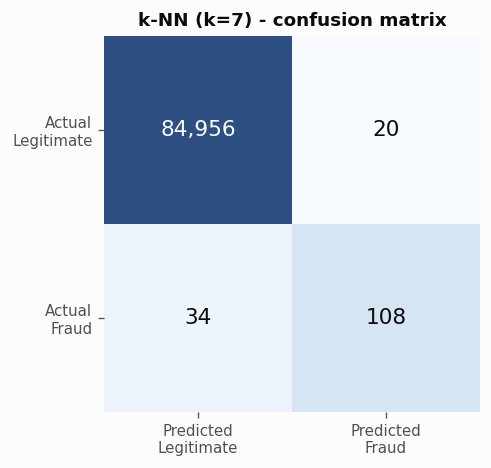

saved figure -> Results/figures/04_pr_curve.png


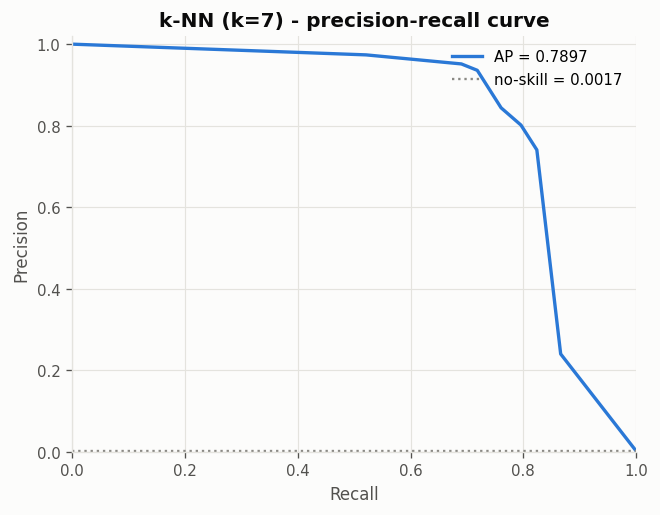

In [11]:
utils.plot_confusion(y_test, y_pred, f"k-NN (k={best_k}) - confusion matrix",
                     "04_confusion.png"); plt.show()
utils.plot_pr_curve(y_test, y_proba, f"k-NN (k={best_k}) - precision-recall curve",
                    "04_pr_curve.png"); plt.show()

## 6. Distance weighting

A refinement of plain majority voting: weight each neighbour's vote by
$1/d^2$, so that closer neighbours count for more. This makes the prediction
less sensitive to the exact choice of k.

In [12]:
knn_w = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k, weights="distance", n_jobs=-1)),
]).fit(X_sub, y_sub)

pw = knn_w.predict(X_test); pr = knn_w.predict_proba(X_test)[:, 1]
from sklearn.metrics import f1_score, average_precision_score
print(f"uniform weighting  : F1 = {f1_score(y_test, y_pred):.4f}   "
      f"PR-AUC = {average_precision_score(y_test, y_proba):.4f}")
print(f"distance weighting : F1 = {f1_score(y_test, pw):.4f}   "
      f"PR-AUC = {average_precision_score(y_test, pr):.4f}")

uniform weighting  : F1 = 0.8000   PR-AUC = 0.7897
distance weighting : F1 = 0.8165   PR-AUC = 0.8143


## 7. The curse of dimensionality and k-NN

Notebook 02 showed that as dimensions are added, the nearest and farthest
neighbours of a point become increasingly similar in distance. k-NN depends
entirely on "nearest" being meaningful, so it is the algorithm most directly
harmed by this.

The experiment below measures the effect on our own data by training k-NN on
progressively more attributes, ordered by the information gain computed in
Notebook 03.

In [13]:
order_cols = ["V14","V17","V12","V10","V16","V11","V9","V4","V18","V3",
              "V7","V2","V21","Amount","V19","Time"]
rows = []
for d in [2, 4, 8, 12, 16]:
    cols = order_cols[:d]
    p = Pipeline([("scaler", StandardScaler()),
                  ("knn", KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1))])
    p.fit(X_sub[cols], y_sub)
    pr_ = p.predict_proba(X_test[cols])[:, 1]
    ap = average_precision_score(y_test, pr_)
    rows.append({"n_attributes": d, "pr_auc": ap})
    print(f"  {d:>2} attributes : PR-AUC = {ap:.4f}")

# and with all 30
rows.append({"n_attributes": 30, "pr_auc": average_precision_score(y_test, y_proba)})
print(f"  30 attributes : PR-AUC = {rows[-1]['pr_auc']:.4f}")
cd_df = pd.DataFrame(rows)

   2 attributes : PR-AUC = 0.7660


   4 attributes : PR-AUC = 0.8092


   8 attributes : PR-AUC = 0.8140


  12 attributes : PR-AUC = 0.8180


  16 attributes : PR-AUC = 0.8063
  30 attributes : PR-AUC = 0.7897


saved figure -> Results/figures/04_dimensionality_effect.png


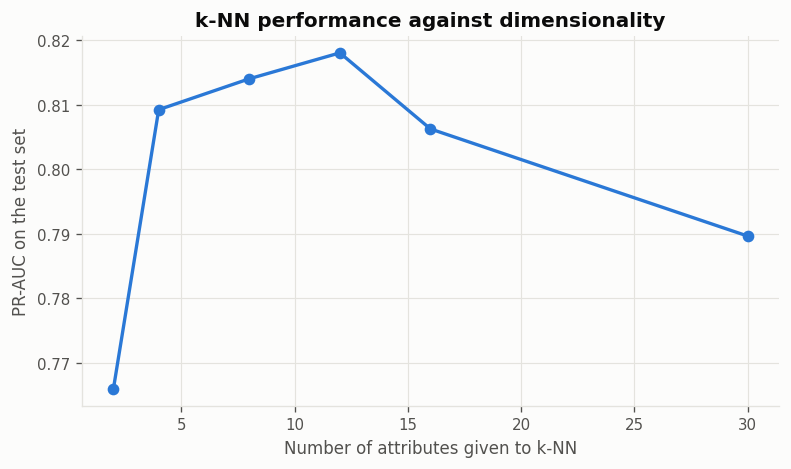

,n_attributes,pr_auc
0,2,0.7660
1,4,0.8092
2,8,0.8140
3,12,0.8180
4,16,0.8063
5,30,0.7897


In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(cd_df["n_attributes"], cd_df["pr_auc"], marker="o", color=utils.BLUE)
ax.set_xlabel("Number of attributes given to k-NN")
ax.set_ylabel("PR-AUC on the test set")
ax.set_title("k-NN performance against dimensionality")
utils.despine(ax)
utils.save_fig(fig, "04_dimensionality_effect.png")
plt.show()
cd_df.round(4)

Performance peaks with a modest number of well-chosen attributes and then
**declines** as more are added, even though the extra attributes contain genuine
information. This is the curse of dimensionality acting on a real dataset: the
added dimensions dilute the distance measure faster than they contribute signal.
It is also a concrete argument for the feature selection work in Notebook 02.

## 8. Summary

- k-NN stores the training data and classifies by majority vote among the k
  nearest stored examples; it builds no model and approximates the target
  function locally rather than globally.
- Standardisation is mandatory, because Euclidean distance would otherwise be
  dominated by `Amount`.
- The hand-worked numerical example reproduces scikit-learn's neighbours,
  distances and prediction exactly.
- k was chosen by cross validation rather than left at 1, which would overfit.
- k-NN performance **falls** when too many attributes are supplied, confirming
  the curse of dimensionality on this dataset.
- Its practical weakness here is cost: prediction requires comparing each of the
  85,118 test transactions against every stored training point, which is why the
  training set had to be subsampled.